In [1]:
import  numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.externals.array_api_compat.cupy import linspace

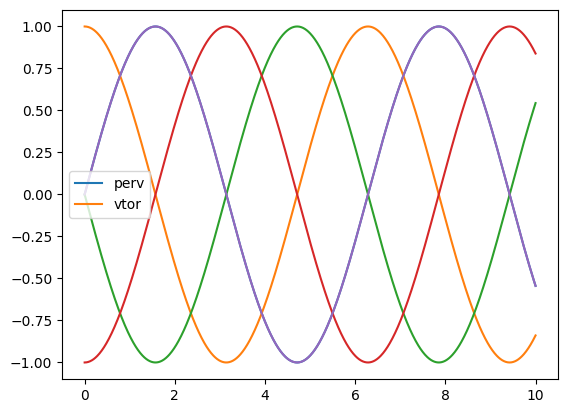

In [45]:
x = np.linspace(0, 10, 1000)
# plt.axis("equal")
# fig, ax = plt.subplots()
# ax.plot(x, np.sin(x),"-k" ,label="sin(x)")
# ax.plot(x, np.cos(x),"--r" ,label="cos(x)")
# ax.axis("equal")
# ax.legend(frameon=True, shadow=True, borderpad = 0.5, loc="lower center", ncol=2)
y = np.sin(x[:, np.newaxis] + np.pi * np.arange(0, 2.01, 0.5))
# plt.plot(x, y)
# lines = plt.plot(x, y)
# plt.legend(lines, ['1','2','3'])
plt.plot(x, y[:,0], label='perv')
plt.plot(x, y[:,1], label='vtor')
plt.plot(x, y[:,2:])

plt.legend()

plt.show()

   Unnamed: 0         city       latd       longd  elevation_m  elevation_ft  \
0           0     Adelanto  34.576111 -117.432778        875.0        2871.0   
1           1  AgouraHills  34.153333 -118.761667        281.0         922.0   
2           2      Alameda  37.756111 -122.274444          NaN          33.0   
3           3       Albany  37.886944 -122.297778          NaN          43.0   
4           4     Alhambra  34.081944 -118.135000        150.0         492.0   

   population_total  area_total_sq_mi  area_land_sq_mi  area_water_sq_mi  \
0             31765            56.027           56.009             0.018   
1             20330             7.822            7.793             0.029   
2             75467            22.960           10.611            12.349   
3             18969             5.465            1.788             3.677   
4             83089             7.632            7.631             0.001   

   area_total_km2  area_land_km2  area_water_km2  area_water_p

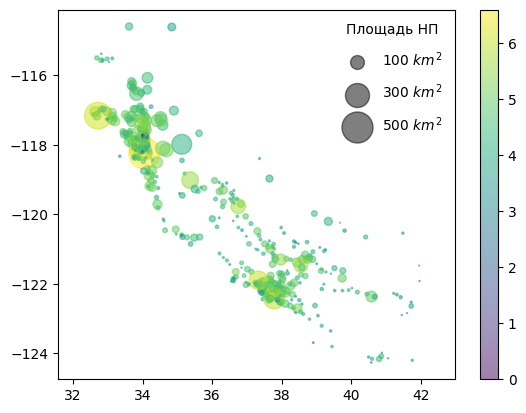

In [65]:
cities = pd.read_csv('/Users/adil.murat/PycharmProjects/ml_formula/data/california_cities.csv')
print(cities.head())

latd = cities['latd']
longd = cities['longd']
population_total = cities['population_total']
area_total_sq_mi = cities['area_total_sq_mi']

plt.scatter(
    latd,
    longd,
    c= np.log10(population_total),
    s= area_total_sq_mi, alpha= 0.5,
)
plt.colorbar()
plt.scatter([],[], s= 100, c='k', alpha=0.5, label='100 $km^2$')
plt.scatter([],[], s= 300, c='k', alpha=0.5, label='300 $km^2$')
plt.scatter([],[], s= 500, c='k', alpha=0.5, label='500 $km^2$')
plt.legend(frameon=False, labelspacing=1, title='Площадь НП')

plt.axis('equal')
plt.show()

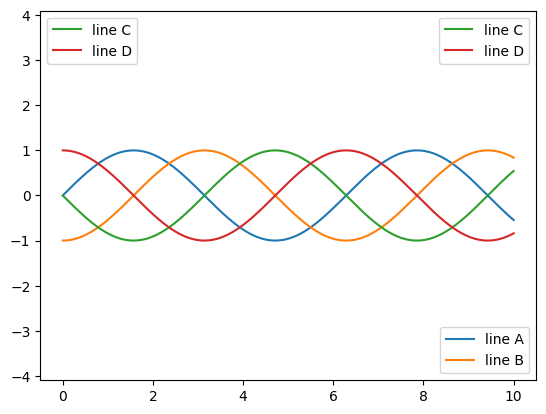

In [72]:
import matplotlib as mpl

fig, ax = plt.subplots()
lines = ax.plot(x, np.sin(x[:, np.newaxis]-np.pi/2*np.arange(0, 4, 1)))
ax.axis('equal')

ax.legend(lines[:2], ['line A', 'line B'], loc='lower right')
leg = mpl.legend.Legend(ax, lines[2:], ['line C', 'line D'], loc='upper right')
ax.add_artist(leg)
leg2 = mpl.legend.Legend(ax, lines[2:], ['line C', 'line D'], loc='upper left')
ax.add_artist(leg2)
plt.show()

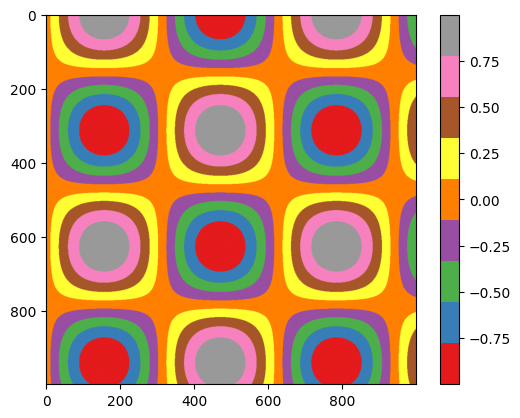

In [88]:
y = np.sin(x) * np.cos(x[:, np.newaxis])

# plt.imshow(y, cmap='jet')
# plt.imshow(y, cmap='viridis')
# plt.imshow(y, cmap='RdBu')
plt.imshow(y, cmap='Set1')
plt.colorbar()

plt.show()

/var/folders/6p/5mscwz31629gyb0h0hz8t8xw0000gn/T/ipykernel_3119/2236170533.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('jet',6)


<function matplotlib.pyplot.show(close=None, block=None)>

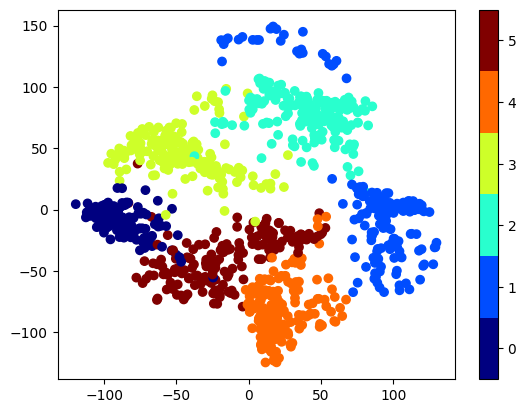

In [109]:
from sklearn.datasets import load_digits

digits = load_digits(n_class=6)
# fig, ax = plt.subplots(8,8)
# for i,ax in enumerate(ax.flat):
#     ax.imshow(digits.images[i], cmap='binary')
#     ax.set(xticks=[], yticks=[])

from sklearn.manifold import Isomap
iso = Isomap(n_components=2, n_neighbors=10)
prj = iso.fit_transform(digits.data)

plt.scatter(
    prj[:, 0],
    prj[:, 1],
    c=digits.target,
    cmap = plt.cm.get_cmap('jet', 6)
)

from sklearn.decomposition import PCA

plt.colorbar(ticks = range(6))
plt.clim(-0.5, 5.5)

plt.show